#**Sequence to Sequence Langauge Translator**

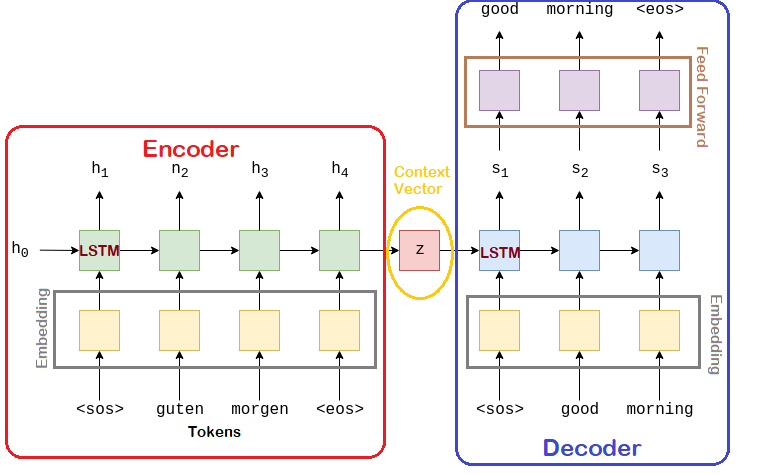

#**Workflow**

1. Import importent liaberies

2. Data preparation (Spicy)

3. Build Seq2seq model

4. Weights Initialization

4. Pick a loss function and optimizere

4. Training function and eval function

6. Visulize model

7. Evaluating Model

#**1. Import importent liaberies**

In [1]:
!pip install datasets evaluate --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 21.6 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [2]:
!pip uninstall -y torch torchvision torchtext
!pip install torch==2.3.0 torchvision==0.18.0 torchtext==0.18.0

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 119.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import spacy
import datasets
import torchtext
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import evaluate
import tqdm as tqdm
import random

In [4]:
print(torch.__version__)

2.3.0+cu121


**Device**

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

#**2. Prepare Dataset**

1. Loading your data
2. tokenize your data with spacy
3. creating a vocabulary
4. numericalizing our data
5. convert data into tensors
6. creating data loader (batches)

##**2.1 Loading your data**

In [6]:
from huggingface_hub import login
from google.colab import userdata

user = userdata.get("HF_TOKEN")

if user:
  login(user)
  print("User Successfully logged in to Hugging Face.")

else:
  print("User not found")

User Successfully logged in to Hugging Face.


In [7]:
dataset = datasets.load_dataset("bentrevett/multi30k")

README.md: 0.00B [00:00, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

val.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/29000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1014 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [8]:
dataset

DatasetDict({
    train: Dataset({
        features: ['en', 'de'],
        num_rows: 29000
    })
    validation: Dataset({
        features: ['en', 'de'],
        num_rows: 1014
    })
    test: Dataset({
        features: ['en', 'de'],
        num_rows: 1000
    })
})

In [9]:
dataset['train'][0]

{'en': 'Two young, White males are outside near many bushes.',
 'de': 'Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.'}

In [10]:
train_data, valid_data, test_data = (dataset["train"],
                                            dataset["validation"],
                                            dataset["test"])

In [11]:
train_data

Dataset({
    features: ['en', 'de'],
    num_rows: 29000
})

In [12]:
valid_data

Dataset({
    features: ['en', 'de'],
    num_rows: 1014
})

In [13]:
test_data

Dataset({
    features: ['en', 'de'],
    num_rows: 1000
})

In [14]:
train_data[0]

{'en': 'Two young, White males are outside near many bushes.',
 'de': 'Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.'}

##**2.2 tokenize your data with spacy**

In [15]:
# Import tokenizer model from spacy
!python -m spacy download en_core_web_sm
!python -m spacy download de_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 115.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 82.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [16]:
en_nlp = spacy.load("en_core_web_sm")
de_nlp = spacy.load("de_core_news_sm")

In [17]:
train_data["en"][0]

'Two young, White males are outside near many bushes.'

In [18]:
[token.text for token in en_nlp.tokenizer(train_data["en"][0])]

['Two',
 'young',
 ',',
 'White',
 'males',
 'are',
 'outside',
 'near',
 'many',
 'bushes',
 '.']

In [19]:
train_data["de"][0]

'Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.'

In [20]:
[token.text for token in de_nlp.tokenizer(train_data["de"][0])]

['Zwei',
 'junge',
 'weiße',
 'Männer',
 'sind',
 'im',
 'Freien',
 'in',
 'der',
 'Nähe',
 'vieler',
 'Büsche',
 '.']

In [21]:
def tokenize_example(example, en_nlp, de_nlp, max_length, lower, sos_token, eos_token):
    # For english
    en_tokens = [token.text for token in en_nlp.tokenizer(example["en"])][:max_length]

    # For douch
    de_tokens = [token.text for token in de_nlp.tokenizer(example["de"])][:max_length]

    # lower case
    if lower:
        en_tokens = [token.lower() for token in en_tokens]
        de_tokens = [token.lower() for token in de_tokens]
    en_tokens = [sos_token] + en_tokens + [eos_token]
    de_tokens = [sos_token] + de_tokens + [eos_token]
    return {"en_tokens": en_tokens, "de_tokens": de_tokens}


In [22]:
max_length = 1_000
lower = True
sos_token = "<sos>"
eos_token = "<eos>"

fn_kwargs = {
    "en_nlp": en_nlp,
    "de_nlp": de_nlp,
    "max_length": max_length,
    "lower": lower,
    "sos_token": sos_token,
    "eos_token": eos_token,
}

In [23]:
train_data = train_data.map(tokenize_example, fn_kwargs=fn_kwargs)
valid_data = valid_data.map(tokenize_example, fn_kwargs=fn_kwargs)
test_data = test_data.map(tokenize_example, fn_kwargs=fn_kwargs)

Map:   0%|          | 0/29000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1014 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [24]:
train_data

Dataset({
    features: ['en', 'de', 'en_tokens', 'de_tokens'],
    num_rows: 29000
})

In [25]:
train_data[0]

{'en': 'Two young, White males are outside near many bushes.',
 'de': 'Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.',
 'en_tokens': ['<sos>',
  'two',
  'young',
  ',',
  'white',
  'males',
  'are',
  'outside',
  'near',
  'many',
  'bushes',
  '.',
  '<eos>'],
 'de_tokens': ['<sos>',
  'zwei',
  'junge',
  'weiße',
  'männer',
  'sind',
  'im',
  'freien',
  'in',
  'der',
  'nähe',
  'vieler',
  'büsche',
  '.',
  '<eos>']}

##**2.3 creating a vocabulary**

In [26]:
min_freq = 2
unk_token = "<unk>"
pad_token = "<pad>"
special_token = [unk_token, pad_token, sos_token, eos_token]

In [27]:
from torchtext.vocab import build_vocab_from_iterator

en_vocab = build_vocab_from_iterator(
    train_data["en_tokens"],
    min_freq=min_freq,
    specials = special_token
)

de_vocab = build_vocab_from_iterator(
    train_data["de_tokens"],
    min_freq = min_freq,
    specials = special_token
)

/usr/local/lib/python3.12/dist-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)


In [28]:
en_vocab.get_itos()[0:20]

['<unk>',
 '<pad>',
 '<sos>',
 '<eos>',
 'a',
 '.',
 'in',
 'the',
 'on',
 'man',
 'is',
 'and',
 'of',
 'with',
 'woman',
 ',',
 'two',
 'are',
 'to',
 'people']

In [29]:
len(en_vocab.get_itos())

5893

In [30]:
len(de_vocab.get_itos())

7853

In [31]:
en_vocab.get_stoi()["<pad>"]

1

In [32]:
"possible" in en_vocab

True

In [33]:
assert en_vocab[unk_token] == de_vocab[unk_token]
assert en_vocab[pad_token] == de_vocab[pad_token]

unk_index =  en_vocab[unk_token]
pad_index = en_vocab[pad_token]

In [34]:
en_vocab.set_default_index(unk_index)
de_vocab.set_default_index(unk_index)

In [35]:
de_vocab["jhjduwi9"]

0

In [36]:
sample_tokens = ["bag", "crime", "reliable", "poor", "nxjkhasjd2732"]
en_vocab.lookup_indices(sample_tokens)

[265, 0, 0, 1927, 0]

##**2.4 numericalizing our data**

In [37]:
train_data

Dataset({
    features: ['en', 'de', 'en_tokens', 'de_tokens'],
    num_rows: 29000
})

Only need to numerize this 'en_tokens' and 'de_tokens' columns.

In [38]:
def numerize_example(example, en_vocab, de_vocab):
    en_ids = en_vocab.lookup_indices(example["en_tokens"])
    de_ids = de_vocab.lookup_indices(example["de_tokens"])

    return {"en_ids": en_ids, "de_ids": de_ids}

In [39]:
fn_kwargs = {"en_vocab":en_vocab , "de_vocab":de_vocab}

In [40]:
train_data = train_data.map(numerize_example, fn_kwargs=fn_kwargs)
valid_data = valid_data.map(numerize_example, fn_kwargs=fn_kwargs)
test_data = test_data.map(numerize_example, fn_kwargs=fn_kwargs)

Map:   0%|          | 0/29000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1014 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [41]:
train_data

Dataset({
    features: ['en', 'de', 'en_tokens', 'de_tokens', 'en_ids', 'de_ids'],
    num_rows: 29000
})

In [42]:
train_data[0]

{'en': 'Two young, White males are outside near many bushes.',
 'de': 'Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.',
 'en_tokens': ['<sos>',
  'two',
  'young',
  ',',
  'white',
  'males',
  'are',
  'outside',
  'near',
  'many',
  'bushes',
  '.',
  '<eos>'],
 'de_tokens': ['<sos>',
  'zwei',
  'junge',
  'weiße',
  'männer',
  'sind',
  'im',
  'freien',
  'in',
  'der',
  'nähe',
  'vieler',
  'büsche',
  '.',
  '<eos>'],
 'en_ids': [2, 16, 24, 15, 25, 778, 17, 57, 80, 202, 1312, 5, 3],
 'de_ids': [2, 18, 26, 253, 30, 84, 20, 88, 7, 15, 110, 7647, 3171, 4, 3]}

##**2.5 convert data into tensors**

In [43]:
data_type = "torch"
columns = ["en_ids","de_ids"]

In [44]:
train_data = train_data.with_format(
    type=data_type,
    columns=columns,
    output_all_columns=True
)

valid_data = valid_data.with_format(
    type=data_type,
    columns=columns,
    output_all_columns=True,
)

test_data = test_data.with_format(
    type=data_type,
    columns=columns,
    output_all_columns=True,
)

In [45]:
type(train_data[0]["en_ids"])

torch.Tensor

In [46]:
type(train_data[0]["de_ids"])

torch.Tensor

##**2.6 creating data loader (batches)**

In [47]:
batch_size = 128

In [48]:
def get_collate_fn(pad_index):
    def collate_fn(batch):
        batch_en_ids = [example["en_ids"] for example in batch]
        batch_de_ids = [example["de_ids"] for example in batch]
        batch_en_ids = nn.utils.rnn.pad_sequence(batch_en_ids, padding_value=pad_index)
        batch_de_ids = nn.utils.rnn.pad_sequence(batch_de_ids, padding_value=pad_index)
        batch = {
            "en_ids": batch_en_ids,
            "de_ids": batch_de_ids,
        }
        return batch

    return collate_fn

In [49]:
def get_data_loader(dataset, batch_size, pad_index, shuffle=False):
    collate_fn = get_collate_fn(pad_index)
    data_loader = torch.utils.data.DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        collate_fn=collate_fn,
        shuffle=shuffle,
    )
    return data_loader

In [50]:
batch_size = 128

In [51]:
train_data_loader = get_data_loader(train_data, batch_size, pad_index, shuffle=True)

valid_data_loader = get_data_loader(valid_data, batch_size, pad_index)

test_data_loader = get_data_loader(test_data, batch_size, pad_index)

In [52]:
len(train_data_loader)

227

In [53]:
len(valid_data_loader)

8

In [54]:
len(test_data_loader)

8

In [55]:
train_data

Dataset({
    features: ['en', 'de', 'en_tokens', 'de_tokens', 'en_ids', 'de_ids'],
    num_rows: 29000
})

#**3. Build Seq2seq model**

###**Encoder**

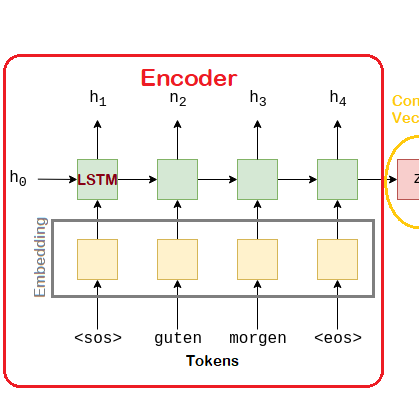

In [56]:
class Encoder(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        self.embedding = nn.Embedding(input_dim, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, n_layers, dropout=dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, (hidden, cell) = self.lstm(embedded)

        return hidden, cell

###**Decoder**

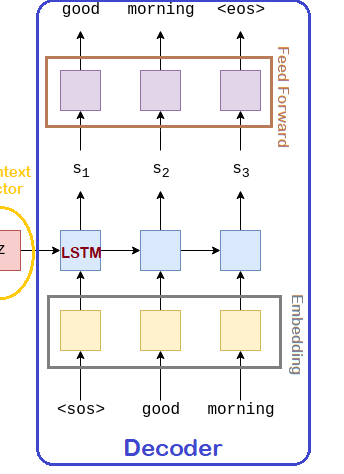

In [57]:
class Decoder(nn.Module):
    def __init__(self, output_dim, embedding_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.output_dim = output_dim
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        self.embedding = nn.Embedding(output_dim, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, n_layers, dropout=dropout)
        self.fc_out = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, cell):
        input = input.unsqueeze(0)
        embedded = self.dropout(self.embedding(input))
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        prediction = self.fc_out(output.squeeze(0))

        return prediction, hidden, cell

###**Seq 2 Seq Model**

In [58]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
        assert (
            encoder.hidden_dim == decoder.hidden_dim
        ), "Hidden dimensions of encoder and decoder must be equal!"
        assert (
            encoder.n_layers == decoder.n_layers
        ), "Encoder and decoder must have equal number of layers!"

    def forward(self, src, trg, teacher_forcing_ratio):
        batch_size = trg.shape[1]
        trg_length = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim
        outputs = torch.zeros(trg_length, batch_size, trg_vocab_size).to(self.device)
        # last hidden state of the encoder is used as the initial hidden state of the decoder
        hidden, cell = self.encoder(src)
        input = trg[0, :]
        for t in range(1, trg_length):
        # last hidden state of the encoder is used as the initial hidden state of the decoder
            output, hidden, cell = self.decoder(input, hidden, cell)
            outputs[t] = output
            # decide if we are going to use teacher forcing or not
            teacher_force = random.random() < teacher_forcing_ratio
            # get the highest predicted token from our predictions
            top1 = output.argmax(1)
            input = trg[t] if teacher_force else top1

        return outputs

In [59]:
input_dim = len(de_vocab)
output_dim = len(en_vocab)
encoder_embedding_dim = 256
decoder_embedding_dim = 256
hidden_dim = 512
n_layers = 2
encoder_dropout = 0.5
decoder_dropout = 0.5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder = Encoder(
    input_dim,
    encoder_embedding_dim,
    hidden_dim,
    n_layers,
    encoder_dropout,
)

decoder = Decoder(
    output_dim,
    decoder_embedding_dim,
    hidden_dim,
    n_layers,
    decoder_dropout,
)

In [60]:
model = Seq2Seq(encoder, decoder, device).to(device)

In [61]:
model

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(7853, 256)
    (lstm): LSTM(256, 512, num_layers=2, dropout=0.5)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(5893, 256)
    (lstm): LSTM(256, 512, num_layers=2, dropout=0.5)
    (fc_out): Linear(in_features=512, out_features=5893, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)

#**4. Weights Initialization**

In [62]:
# Uniform Distribution (-0.08 to +0.08)

In [63]:
def init_weights(m):
    for name, param in m.named_parameters():
        nn.init.uniform_(param.data, -0.08, 0.08)

model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(7853, 256)
    (lstm): LSTM(256, 512, num_layers=2, dropout=0.5)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(5893, 256)
    (lstm): LSTM(256, 512, num_layers=2, dropout=0.5)
    (fc_out): Linear(in_features=512, out_features=5893, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)

In [64]:
trainable_parameters = sum(p.numel() for p in model.parameters())
print(f"The model have {trainable_parameters:,} trainable parameters.")

The model have 13,898,501 trainable parameters.


The model have **13M** trainable parameters.

#**5. Pick a loss function and optimizere**

**Loss Function**

In [65]:
criterion = nn.CrossEntropyLoss(ignore_index=pad_index)

**Optimizer**

In [66]:
optimizer = optim.Adam(model.parameters())

#**6. Training function and eval function**

##**Training function**

In [67]:
def train_fn(
    model, data_loader, optimizer, criterion, clip, teacher_forcing_ratio, device
):
    model.train()
    epoch_loss = 0
    for i, batch in enumerate(data_loader):
        src = batch["de_ids"].to(device)
        trg = batch["en_ids"].to(device)

        optimizer.zero_grad()
        output = model(src, trg, teacher_forcing_ratio)

        output_dim = output.shape[-1]
        output = output[1:].view(-1, output_dim)

        trg = trg[1:].view(-1)

        loss = criterion(output, trg)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(data_loader)

##**Evaluate function**

In [68]:
def evaluate_fn(model, data_loader, criterion, device):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for i, batch in enumerate(data_loader):
            src = batch["de_ids"].to(device)
            trg = batch["en_ids"].to(device)

            output = model(src, trg, 0)  # turn off teacher forcing

            output_dim = output.shape[-1]
            output = output[1:].view(-1, output_dim)

            trg = trg[1:].view(-1)

            loss = criterion(output, trg)
            epoch_loss += loss.item()
    return epoch_loss / len(data_loader)

## **Model Training**

In [69]:
n_epochs = 20
clip = 1.0  # for resolve exploring dradient
teacher_forcing_ratio = 0.5
best_valid_loss = float("inf")

In [70]:
train_losses = []
valid_losses = []
train_ppls = []
valid_ppls = []

In [71]:
for epoch in tqdm.tqdm(range(n_epochs)):
    train_loss = train_fn(
        model,
        train_data_loader,
        optimizer,
        criterion,
        clip,
        teacher_forcing_ratio,
        device,
    )

    valid_loss = evaluate_fn(
        model,
        valid_data_loader,
        criterion,
        device,
    )

    train_ppl = np.exp(train_loss)
    valid_ppl = np.exp(valid_loss)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    train_ppls.append(train_ppl)
    valid_ppls.append(valid_ppl)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), "Seq2Seq-model.pt")

    print(f"\tTrain Loss: {train_loss:7.3f} | Train PPL: {train_ppl:7.3f}")
    print(f"\tValid Loss: {valid_loss:7.3f} | Valid PPL: {valid_ppl:7.3f}")

  5%|▌         | 1/20 [00:44<13:57, 44.07s/it]

	Train Loss:   5.042 | Train PPL: 154.782
	Valid Loss:   4.956 | Valid PPL: 142.050


 10%|█         | 2/20 [01:29<13:31, 45.10s/it]

	Train Loss:   4.434 | Train PPL:  84.226
	Valid Loss:   4.725 | Valid PPL: 112.748


 15%|█▌        | 3/20 [02:15<12:51, 45.36s/it]

...

	Train Loss:   2.389 | Train PPL:  10.907
	Valid Loss:   3.657 | Valid PPL:  38.747


 95%|█████████▌| 19/20 [14:41<00:46, 46.44s/it]

	Train Loss:   2.326 | Train PPL:  10.242
	Valid Loss:   3.677 | Valid PPL:  39.519


100%|██████████| 20/20 [15:28<00:00, 46.41s/it]

	Train Loss:   2.240 | Train PPL:   9.396
	Valid Loss:   3.684 | Valid PPL:  39.793


# **7. Visulize model**

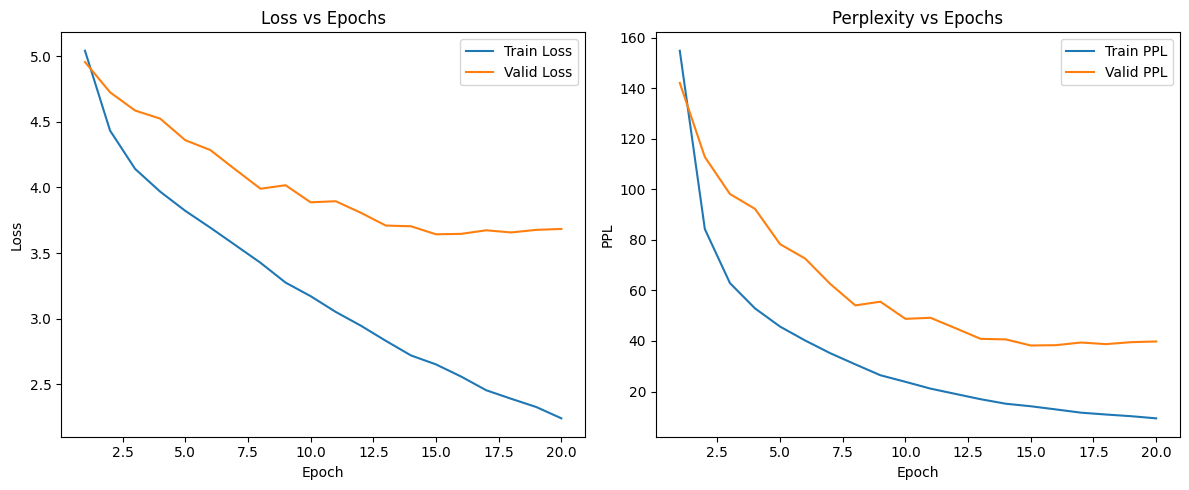

In [72]:
epochs = range(1, n_epochs + 1)

plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, valid_losses, label="Valid Loss")
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Perplexity plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_ppls, label="Train PPL")
plt.plot(epochs, valid_ppls, label="Valid PPL")
plt.title("Perplexity vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("PPL")
plt.legend()

plt.tight_layout()
plt.show()

#**8. Evaluating the Model**

In [73]:
model.load_state_dict(torch.load("Seq2Seq-model.pt"))

<All keys matched successfully>

In [74]:
test_loss = evaluate_fn(model, test_data_loader, criterion, device)

print(f"| Test Loss: {test_loss:.3f} | Test PPL: {np.exp(test_loss):7.3f} |")

| Test Loss: 3.681 | Test PPL:  39.687 |


In [75]:
def translate_sentence(
    sentence,
    model,
    en_nlp,
    de_nlp,
    en_vocab,
    de_vocab,
    lower,
    sos_token,
    eos_token,
    device,
    max_output_length=25,
):
    model.eval()
    with torch.no_grad():
        if isinstance(sentence, str):
            tokens = [token.text for token in de_nlp.tokenizer(sentence)]
        else:
            tokens = [token for token in sentence]
        if lower:
            tokens = [token.lower() for token in tokens]
        tokens = [sos_token] + tokens + [eos_token]
        ids = de_vocab.lookup_indices(tokens)
        tensor = torch.LongTensor(ids).unsqueeze(-1).to(device)
        hidden, cell = model.encoder(tensor)
        inputs = en_vocab.lookup_indices([sos_token])
        for _ in range(max_output_length):
            inputs_tensor = torch.LongTensor([inputs[-1]]).to(device)
            output, hidden, cell = model.decoder(inputs_tensor, hidden, cell)
            predicted_token = output.argmax(-1).item()
            inputs.append(predicted_token)
            if predicted_token == en_vocab[eos_token]:
                break
        tokens = en_vocab.lookup_tokens(inputs)
    return tokens

In [76]:
sentence = test_data[0]["de"]
expected_translation = test_data[0]["en"]

sentence, expected_translation

('Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt.',
 'A man in an orange hat starring at something.')

In [77]:
translation = translate_sentence(
    sentence,
    model,
    en_nlp,
    de_nlp,
    en_vocab,
    de_vocab,
    lower,
    sos_token,
    eos_token,
    device,
)

In [78]:
translation

['<sos>',
 'a',
 'man',
 'in',
 'a',
 'orange',
 'jacket',
 'is',
 'eating',
 'something',
 '.',
 '<eos>']

In [79]:
sentence = "Ein Mann sitzt auf einer Bank."

In [80]:
translation = translate_sentence(
    sentence,
    model,
    en_nlp,
    de_nlp,
    en_vocab,
    de_vocab,
    lower,
    sos_token,
    eos_token,
    device,
)

In [81]:
translation

['<sos>', 'a', 'man', 'sits', 'on', 'a', 'bench', '.', '<eos>']

In [82]:
translations = [
    translate_sentence(
        example["de"],
        model,
        en_nlp,
        de_nlp,
        en_vocab,
        de_vocab,
        lower,
        sos_token,
        eos_token,
        device,
    )
    for example in tqdm.tqdm(test_data)
]

100%|██████████| 1000/1000 [00:08<00:00, 113.67it/s]


In [83]:
bleu = evaluate.load("bleu")

In [84]:
predictions = [" ".join(translation[1:-1]) for translation in translations]

references = [[example["en"]] for example in test_data]

In [85]:
predictions[0], references[0]

('a man in a orange jacket is eating something .',
 ['A man in an orange hat starring at something.'])

In [86]:
def get_tokenizer_fn(nlp, lower):
    def tokenizer_fn(s):
        tokens = [token.text for token in nlp.tokenizer(s)]
        if lower:
            tokens = [token.lower() for token in tokens]
        return tokens

    return tokenizer_fn

In [87]:
tokenizer_fn = get_tokenizer_fn(en_nlp, lower)

In [88]:
tokenizer_fn(predictions[0]), tokenizer_fn(references[0][0])

(['a', 'man', 'in', 'a', 'orange', 'jacket', 'is', 'eating', 'something', '.'],
 ['a', 'man', 'in', 'an', 'orange', 'hat', 'starring', 'at', 'something', '.'])

In [89]:
results = bleu.compute(
    predictions=predictions, references=references, tokenizer=tokenizer_fn
)

In [90]:
results

{'bleu': 0.1632486124319474,
 'precisions': [0.5203110123770232,
  0.22819717338848672,
  0.11420218785364014,
  0.060495626822157436],
 'brevity_penalty': 0.9646207008611563,
 'length_ratio': 0.9652320416602849,
 'translation_length': 12604,
 'reference_length': 13058}